# DiploDatos Kaggle Competition
## Grupo 33

En esta notebook presentamos los modelos de aprendizaje automático creados y presentados en la competencia Kaggle para predecir la diabetes en pacientes en función de su historial médico e información demográfica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import recall_score, ConfusionMatrixDisplay, classification_report

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC

from scipy.stats import uniform, randint




## **Leer el dataset**


### **Train**

Cargamos los datos de entrenamiento que vamos a utilizar para generar nuestro modelo.

In [2]:
train_df = pd.read_csv('diabetes_prediction_dataset_train-labeled.csv')
print(train_df.shape)
print(train_df.describe())

(95000, 10)
             patient           age  hypertension  heart_disease           bmi  \
count   95000.000000  95000.000000  95000.000000   95000.000000  95000.000000   
mean    50016.501389     41.935269      0.075074       0.039463     27.320879   
std     28868.357071     22.514788      0.263512       0.194695      6.626335   
min         1.000000      0.080000      0.000000       0.000000     10.010000   
25%     25021.750000     24.000000      0.000000       0.000000     23.650000   
50%     50024.000000     43.000000      0.000000       0.000000     27.320000   
75%     75024.250000     60.000000      0.000000       0.000000     29.580000   
max    100000.000000     80.000000      1.000000       1.000000     95.690000   

        HbA1c_level  blood_glucose_level      diabetes  
count  95000.000000         95000.000000  95000.000000  
mean       5.527659           138.070537      0.085074  
std        1.070261            40.739962      0.278993  
min        3.500000           

In [3]:
train_df.head()

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,20432,Male,4.0,0,0,never,19.28,3.5,155,0
1,49682,Female,50.0,0,0,former,27.32,5.7,159,0
2,73886,Female,43.0,0,0,never,21.54,4.5,145,0
3,53144,Male,64.0,0,0,current,28.22,6.0,130,0
4,98507,Male,10.0,0,0,No Info,15.46,6.1,140,0


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95000 entries, 0 to 94999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              95000 non-null  int64  
 1   gender               95000 non-null  object 
 2   age                  95000 non-null  float64
 3   hypertension         95000 non-null  int64  
 4   heart_disease        95000 non-null  int64  
 5   smoking_history      95000 non-null  object 
 6   bmi                  95000 non-null  float64
 7   HbA1c_level          95000 non-null  float64
 8   blood_glucose_level  95000 non-null  int64  
 9   diabetes             95000 non-null  int64  
dtypes: float64(3), int64(5), object(2)
memory usage: 7.2+ MB


La columna ***`diabetes`*** es la columna que debemos predecir. En el dataset de Test esta columna tiene valores nulos.

---
### **Test**

Cargamos los datos de test. Estos datos son los que van a utilizar para predecir si las personas tienen diabetes y generar alrchivo `submision.csv` para utilizar en la competencia de Kaggle.

In [5]:
test_df = pd.read_csv('diabetes_prediction_dataset_test.csv')
print(test_df.shape)
print(test_df.describe())

(5000, 10)
            patient          age  hypertension  heart_disease          bmi  \
count   5000.000000  5000.000000   5000.000000    5000.000000  5000.000000   
mean   49696.473600    40.947016      0.070600       0.038600    27.318644   
std    28855.568156    22.537466      0.256181       0.192659     6.832943   
min        7.000000     0.160000      0.000000       0.000000    10.620000   
25%    24720.750000    23.000000      0.000000       0.000000    23.410000   
50%    49522.500000    41.000000      0.000000       0.000000    27.320000   
75%    74686.000000    59.000000      0.000000       0.000000    29.632500   
max    99970.000000    80.000000      1.000000       1.000000    88.760000   

       HbA1c_level  blood_glucose_level  diabetes  
count  5000.000000          5000.000000       0.0  
mean      5.524620           137.821000       NaN  
std       1.078559            40.101933       NaN  
min       3.500000            80.000000       NaN  
25%       4.800000        

In [6]:
test_df.head()

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,49267,Male,53.0,0,0,never,31.99,4.5,126,NaN
1,82280,Female,22.0,0,0,never,25.96,6.6,130,NaN
2,33216,Female,37.0,0,0,never,22.24,6.2,126,NaN
3,94551,Female,29.0,0,0,not current,31.01,5.0,80,NaN
4,43760,Male,30.0,0,0,ever,28.66,6.6,100,NaN


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   patient              5000 non-null   int64  
 1   gender               5000 non-null   object 
 2   age                  5000 non-null   float64
 3   hypertension         5000 non-null   int64  
 4   heart_disease        5000 non-null   int64  
 5   smoking_history      5000 non-null   object 
 6   bmi                  5000 non-null   float64
 7   HbA1c_level          5000 non-null   float64
 8   blood_glucose_level  5000 non-null   int64  
 9   diabetes             0 non-null      float64
dtypes: float64(4), int64(4), object(2)
memory usage: 390.8+ KB


---
## **Analisis de los datos**

Veamos si hay desbalances...

<Axes: xlabel='diabetes'>

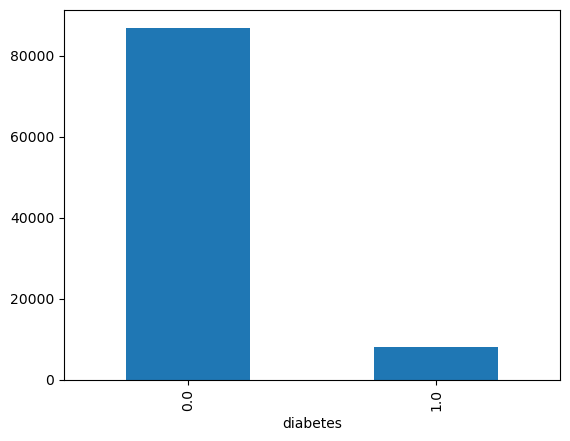

In [8]:
train_df.groupby("patient").diabetes.mean().value_counts().plot(kind='bar')

**¡Clases desbalanceadas!**
Si analizamos por género:

<Axes: xlabel='gender'>

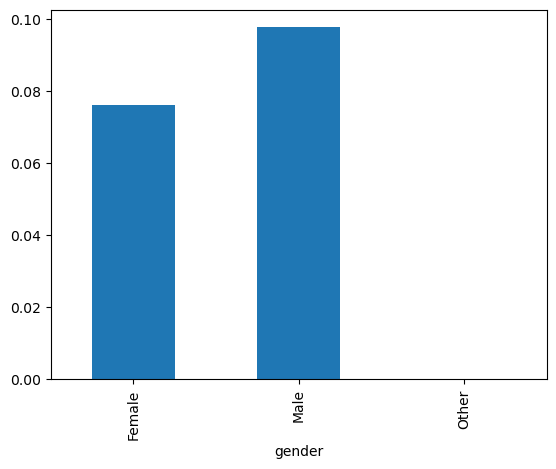

In [9]:
train_df.groupby("gender").diabetes.mean().plot(kind='bar')

Se observa que la mayoría de los registros corresponden a pacientes hombres, con una proporción ligeramente superior a la de mujeres. La categoría ‘Other’ aparece en muy pocos casos, por lo que podría no ser representativa estadísticamente.

También podemos observar por grupo etario:

/tmp/ipykernel_13491/708318605.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(pd.cut(train_df['age'], bins=bins, labels=labels))


<Axes: xlabel='age'>

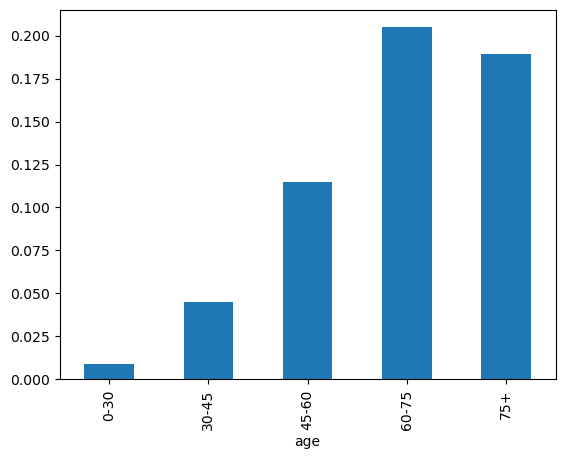

In [10]:
bins = [0, 30, 45, 60, 75, 100]
labels = ['0-30', '30-45', '45-60', '60-75', '75+']

# Agrupar por grupo de edad sin crear columna
(train_df
    .groupby(pd.cut(train_df['age'], bins=bins, labels=labels))
    ['diabetes']
    .mean()
    .plot(kind='bar')
)



Se observa que la mayoría de los pacientes tienen más de 60 años, lo que indica un desbalance etario en el conjunto de datos.
Aun así, esta distribución es coherente con la mayor prevalencia de la enfermedad en edades avanzadas, y permite estudiar su comportamiento en los grupos con mayor riesgo.

Por lo tanto, el conjunto de datos presenta muy poca información sobre pacientes de entre 0 y 30 años y sobre el género ‘Other’.
En consecuencia, un modelo entrenado con estos datos podría tener dificultades para clasificar correctamente a individuos con estas características.

In [11]:
train_df

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,20432,Male,4.0,0,0,never,19.28,3.5,155,0
1,49682,Female,50.0,0,0,former,27.32,5.7,159,0
2,73886,Female,43.0,0,0,never,21.54,4.5,145,0
3,53144,Male,64.0,0,0,current,28.22,6.0,130,0
4,98507,Male,10.0,0,0,No Info,15.46,6.1,140,0
...,...,...,...,...,...,...,...,...,...,...
94995,81090,Female,56.0,0,0,never,22.30,6.2,158,0
94996,90924,Female,24.0,0,0,never,22.50,6.1,126,0
94997,64600,Female,32.0,0,0,never,24.92,6.6,145,0
94998,96132,Female,21.0,0,0,current,20.59,4.5,155,0


Necesitamos contruir nuestros conjuntos de datos para realizar los entrenamientos. Para eso, observemos los valores nulos del dataset de entrenamiento:

In [12]:
train_df.isnull().sum()

patient                0
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

¡No hay valores faltantes! Por lo tanto, no es necesario realizar una imputación.

Ahora, vamos a crear los datos de entrada (´X´) y los de salida (´y´).

In [13]:
#imputer_cols = ["patient", "age", "hypertension", "heart_disease", "bmi" ,"HbA1c_level", "blood_glucose_level", "diabetes"]
#imputer = SimpleImputer(strategy="median")
#train_df[imputer_cols] = imputer.fit_transform(train_df[imputer_cols])
y = train_df.diabetes
X = train_df.drop('diabetes',axis=1)
X

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,20432,Male,4.0,0,0,never,19.28,3.5,155
1,49682,Female,50.0,0,0,former,27.32,5.7,159
2,73886,Female,43.0,0,0,never,21.54,4.5,145
3,53144,Male,64.0,0,0,current,28.22,6.0,130
4,98507,Male,10.0,0,0,No Info,15.46,6.1,140
...,...,...,...,...,...,...,...,...,...
94995,81090,Female,56.0,0,0,never,22.30,6.2,158
94996,90924,Female,24.0,0,0,never,22.50,6.1,126
94997,64600,Female,32.0,0,0,never,24.92,6.6,145
94998,96132,Female,21.0,0,0,current,20.59,4.5,155


Vamos a separar la columna con los Id de los pacientes en una sola variable:

In [14]:
patientId = X.patient
X.drop('patient',axis=1,inplace=True)

Necesitamos transformar las variables que son categoricas a númericas, como por ejemplo **gender** y **smoking_history**. Para esto vamos a utilizar un LabelEncoder.

El uso de LabelEncoder puede generar problemas en algunos modelos, ya que asigna números enteros a variables categóricas, introduciendo un orden artificial que no existe (por ejemplo, en ´gender´).
Esto puede afectar modelos basados en distancias o relaciones lineales, como KNN o regresiones.

En este trabajo utilizamos ´DecisionTree´, ´RandomForest´ y ´XGBoost´, que son modelos basados en árboles y no dependen de distancias ni de supuestos lineales sobre estas variables.
Por lo tanto, el uso de LabelEncoder no genera inconvenientes y, además, evita la creación de múltiples columnas adicionales que produciría un ´OneHotEncoder´, mejorando la eficiencia del entrenamiento.

In [15]:
print(X.columns)
label_cols = ["gender", "smoking_history"]

for col in label_cols:
    X[col] = X[col].astype(str)
    X[col] = LabelEncoder().fit_transform(X[col])
X

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level'],
      dtype='object')


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,1,4.0,0,0,4,19.28,3.5,155
1,0,50.0,0,0,3,27.32,5.7,159
2,0,43.0,0,0,4,21.54,4.5,145
3,1,64.0,0,0,1,28.22,6.0,130
4,1,10.0,0,0,0,15.46,6.1,140
...,...,...,...,...,...,...,...,...
94995,0,56.0,0,0,4,22.30,6.2,158
94996,0,24.0,0,0,4,22.50,6.1,126
94997,0,32.0,0,0,4,24.92,6.6,145
94998,0,21.0,0,0,1,20.59,4.5,155


Además, escalamos las variables numéricas utilizando StandardScaler. Aunque los modelos que más estudiamos son basados en árboles —para los cuales el escalado no es estrictamente necesario—, esta práctica es recomendable para asegurar consistencia y facilitar comparaciones con otros modelos.

In [16]:
x_names = X.columns
X = StandardScaler().fit_transform(X)
X = pd.DataFrame(X, columns=x_names)
X

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,1.185739,-1.684913,-0.284899,-0.202693,0.961962,-1.213479,-1.894556,0.415552
1,-0.842187,0.358199,-0.284899,-0.202693,0.432680,-0.000133,0.161028,0.513736
2,-0.842187,0.047291,-0.284899,-0.202693,0.961962,-0.872414,-0.960200,0.170091
3,1.185739,0.980016,-0.284899,-0.202693,-0.625885,0.135690,0.441335,-0.198100
4,1.185739,-1.418420,-0.284899,-0.202693,-1.155167,-1.789970,0.534771,0.047361
...,...,...,...,...,...,...,...,...
94995,-0.842187,0.624692,-0.284899,-0.202693,0.961962,-0.757720,0.628206,0.489190
94996,-0.842187,-0.796604,-0.284899,-0.202693,0.961962,-0.727537,0.534771,-0.296284
94997,-0.842187,-0.441280,-0.284899,-0.202693,0.961962,-0.362326,1.001949,0.170091
94998,-0.842187,-0.929850,-0.284899,-0.202693,-0.625885,-1.015782,-0.960200,0.415552


A partir de los datos en las variables `X` e `y` separamos en train y en test:

In [17]:
x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state = 8)

---
### **Planteo de modelos**

Planteemos distintos modelos con el fin de observar cómo funcionan por defecto.

In [18]:
clfs =  [DecisionTreeClassifier(),
        RandomForestClassifier(),
        LogisticRegression(),
        MLPClassifier(),
        XGBClassifier(),
        GaussianNB(),
        LinearSVC()]

names = ['Arbol de decisión',
        'Random Forest',
        'Regresión Logística',
        'Perceptrón multicapa',
        'XGBoost',
        'Naive Bayes',
        'SVM']
trained_models = []
accuracy_models = []
for clf,name in zip(clfs,names):
    print(name)
    clf.fit(x_train, y_train)
    train_predictions = clf.predict(x_train)
    recall = recall_score(y_train, train_predictions)
    print(f"Recall train {name}: %.2f%%" % (recall * 100.0))

    train_predictions = clf.predict(x_test)
    recall = recall_score(y_test, train_predictions)
    print("Recall test {name}: %.2f%%" % (recall * 100.0))
    # plot_confusion_matrix(clf,x_test,y_test)
    trained_models.append(clf)
    accuracy_models.append(recall*100)

Arbol de decisión
Recall train Arbol de decisión: 99.10%
Recall test {name}: 75.58%
Random Forest
Recall train Random Forest: 99.08%
Recall test {name}: 70.60%
Regresión Logística
Recall train Regresión Logística: 62.23%
Recall test {name}: 64.64%
Perceptrón multicapa
Recall train Perceptrón multicapa: 67.36%
Recall test {name}: 69.81%
XGBoost
Recall train XGBoost: 72.03%
Recall test {name}: 72.17%
Naive Bayes
Recall train Naive Bayes: 64.67%
Recall test {name}: 65.07%
SVM
Recall train SVM: 59.62%
Recall test {name}: 62.70%


Primero vamos a visualizar cómo funciona el arbol de decisión ajustando los hiperparámetros. Luego, elegimos a XGBoost y a RandomForest como los modelos a utilizar y presentamos los 3 casos (correspondientes a tratar de distinta forma a cada modelo) en los que obtuvimos el mejor score final.

---
### **Ajuste de hiperparámetros para Arbol de Decisión**

In [19]:
grid = GridSearchCV(DecisionTreeClassifier(),
 {'criterion':('gini','entropy'),
 'splitter':("best","random"),
  'min_samples_leaf':(1, 2, 5),
  'min_samples_split':(2, 3, 5, 10, 50, 100),
 'max_depth':(5,10,20)})
grid.fit(x_train,y_train)
grid.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'splitter': 'best'}

Recall train Arbol de decisión: 66.22%
Recall test Arbol de decisión: 69.50%


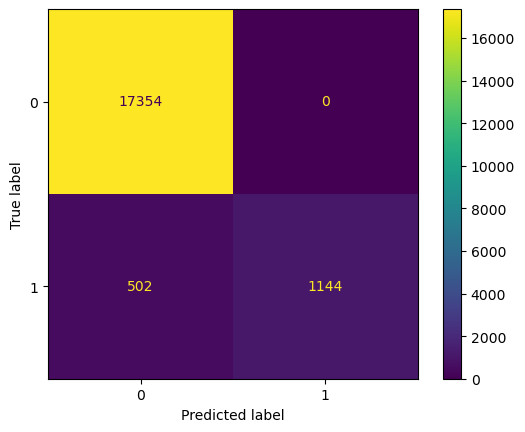

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     17354
           1       1.00      0.70      0.82      1646

    accuracy                           0.97     19000
   macro avg       0.99      0.85      0.90     19000
weighted avg       0.97      0.97      0.97     19000



In [20]:
clf = DecisionTreeClassifier(**grid.best_params_).fit(x_train, y_train)

train_predictions = clf.predict(x_train)
recall = recall_score(y_train, train_predictions)
print("Recall train Arbol de decisión: %.2f%%" % (recall * 100.0))

test_predictions = clf.predict(x_test)
recall = recall_score(y_test, test_predictions)
print("Recall test Arbol de decisión: %.2f%%" % (recall * 100.0))
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions)
plt.show()

print(classification_report(y_test,clf.predict(x_test)))

In [21]:
FOLDS=5
cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=10)

x_train2 = np.array(x_train)
y_train2 = np.array(y_train)


for clfi, name in zip([DecisionTreeClassifier(**grid.best_params_)],names):
    print(clfi)
    avg_recall = 0
    for fold, (train_idx, val_idx) in enumerate(cv.split(x_train2, y_train2)):
        xi, yi = x_train2[train_idx], y_train2[train_idx]
        x_valid, y_valid = x_train2[val_idx], y_train2[val_idx]
        clfi = clfi.fit(xi, yi)

        test_predictions = clfi.predict(x_valid)
        recall = recall_score(y_valid, test_predictions)
        avg_recall +=recall
        print(f"Recall test fold {fold}: {recall * 100.0 :.2f}" % ())

    avg_recall /= FOLDS
    print(f'Avg. recall = {avg_recall * 100}')

DecisionTreeClassifier(max_depth=5)
Recall test fold 0: 67.21
Recall test fold 1: 66.12
Recall test fold 2: 66.43
Recall test fold 3: 65.03
Recall test fold 4: 66.30
Avg. recall = 66.22124252559036


---
## **Generar la salida para entregar**

In [22]:
test_df = pd.read_csv('diabetes_prediction_dataset_test.csv')


In [23]:
test_df

,patient,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,49267,Male,53.0,0,0,never,31.99,4.5,126,NaN
1,82280,Female,22.0,0,0,never,25.96,6.6,130,NaN
2,33216,Female,37.0,0,0,never,22.24,6.2,126,NaN
3,94551,Female,29.0,0,0,not current,31.01,5.0,80,NaN
4,43760,Male,30.0,0,0,ever,28.66,6.6,100,NaN
...,...,...,...,...,...,...,...,...,...,...
4995,88540,Female,23.0,0,0,never,22.77,6.6,200,NaN
4996,26701,Female,51.0,0,0,No Info,27.32,4.0,155,NaN
4997,47271,Male,79.0,0,0,No Info,23.80,6.0,126,NaN
4998,97941,Male,24.0,0,0,never,22.68,6.1,85,NaN


Para poder evaluar nuestra predicción los datos de prueba deben tener exactamente el mismo tratamiento que los datos de entrenamiento

In [24]:
Y_test = test_df.diabetes
PatientId_test = test_df['patient']
X_test = test_df.drop(['patient','diabetes'],axis=1,inplace=True)


In [25]:
X_test = test_df

Notemos que tampoco tienen datos faltantes:

In [26]:
test_df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
dtype: int64

In [27]:
#imputer_cols = ["age", "hypertension", "heart_disease", "bmi" ,"HbA1c_level", "blood_glucose_level"]
#imputer = SimpleImputer(strategy="median")
#X_test[imputer_cols] = imputer.fit_transform(X_test[imputer_cols])

In [28]:
label_cols = ["gender", "smoking_history"]

for col in label_cols:
    X_test[col] = X_test[col].astype(str)
    X_test[col] = LabelEncoder().fit_transform(X_test[col])
X_test

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,1,53.0,0,0,4,31.99,4.5,126
1,0,22.0,0,0,4,25.96,6.6,130
2,0,37.0,0,0,4,22.24,6.2,126
3,0,29.0,0,0,5,31.01,5.0,80
4,1,30.0,0,0,2,28.66,6.6,100
...,...,...,...,...,...,...,...,...
4995,0,23.0,0,0,4,22.77,6.6,200
4996,0,51.0,0,0,0,27.32,4.0,155
4997,1,79.0,0,0,0,23.80,6.0,126
4998,1,24.0,0,0,4,22.68,6.1,85


In [29]:
cols = X_test.columns
X_test = StandardScaler().fit_transform(X_test)
X_test = pd.DataFrame(X_test, columns=cols)

In [30]:
X_test

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,1.216115,0.534851,-0.275614,-0.200374,0.989602,0.683720,-0.950085,-0.294803
1,-0.819565,-0.840774,-0.275614,-0.200374,0.989602,-0.198857,0.997153,-0.195048
2,-0.819565,-0.175149,-0.275614,-0.200374,0.989602,-0.743333,0.626250,-0.294803
3,-0.819565,-0.530149,-0.275614,-0.200374,1.517446,0.540283,-0.486457,-1.441995
4,1.216115,-0.485774,-0.275614,-0.200374,-0.066086,0.196327,0.997153,-0.943216
...,...,...,...,...,...,...,...,...
4995,-0.819565,-0.796399,-0.275614,-0.200374,0.989602,-0.665760,0.997153,1.550679
4996,-0.819565,0.446101,-0.275614,-0.200374,-1.121774,0.000198,-1.413713,0.428426
4997,1.216115,1.688601,-0.275614,-0.200374,-1.121774,-0.515004,0.440799,-0.294803
4998,1.216115,-0.752024,-0.275614,-0.200374,0.989602,-0.678933,0.533525,-1.317300


Este X_test lo vamos a usar siempre para comparar con los datos de testeo.

Generamos la salida

In [31]:
test_id = PatientId_test
test_pred = np.int64(clf.predict(X_test))

Con el resultado predicho tenemos que generar el archivo `.csv` para subir a la competencia de kaggle:

In [32]:
submission = pd.DataFrame(list(zip(test_id, test_pred)), columns=["patient", "diabetes"])
submission.to_csv("sample_submission_tree.csv", header=True, index=False)

In [33]:
submission

,patient,diabetes
0,49267,0
1,82280,0
2,33216,0
3,94551,0
4,43760,0
...,...,...
4995,88540,0
4996,26701,0
4997,47271,0
4998,97941,0


---
## **Prueba con otros modelos**

En esta seccion tenemos aquellos modelos con los que logramos obtener un recall mayor a 90.
Aparte de los exhibidos probamos con SVM, LightGBM, Naive Bayes y Red Neuronal.

---
### **XGBoost 1**

Primer modelo de XGBoost.


In [34]:
import xgboost as xgb

Iniciando RandomizedSearchCV para XGBoost...
RandomizedSearchCV para XGBoost finalizado.

Mejores parámetros para XGBoost: {'alpha': 0.07455064367977082, 'colsample_bytree': 0.9947547746402069, 'eval_metric': 'logloss', 'gamma': 0.3861223846483287, 'lambda': 1.3974313630683448, 'learning_rate': 0.01165663513708072, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 180, 'objective': 'binary:logistic', 'scale_pos_weight': 10.808576755748913, 'subsample': 0.88453678109946}

Recall en el conjunto de prueba con XGBoost (mejores parámetros): 93.86%


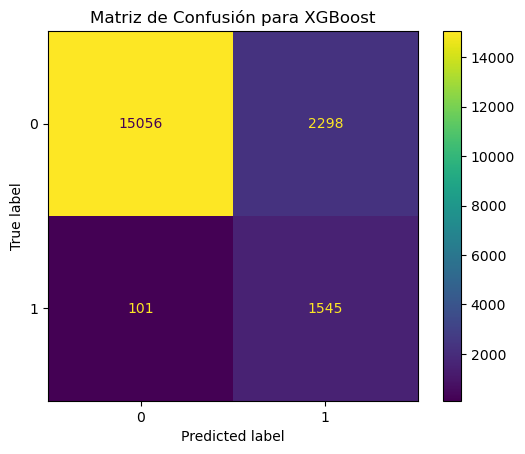


Reporte de Clasificación para XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.87      0.93     17354
           1       0.40      0.94      0.56      1646

    accuracy                           0.87     19000
   macro avg       0.70      0.90      0.74     19000
weighted avg       0.94      0.87      0.89     19000



In [35]:
# Definimos el espacio de búsqueda para XGBoost
param_distributions_xgb = {
    'objective': ['binary:logistic'], # Para clasificación binaria
    'eval_metric': ['logloss'], # Métrica de evaluación durante el entrenamiento
    'n_estimators': randint(100, 500), # Número de árboles (iteraciones de boosting)
    'learning_rate': uniform(0.01, 0.3), # Tasa de aprendizaje
    'max_depth': randint(3, 10), # Profundidad máxima de cada árbol
    'min_child_weight': randint(1, 10), # Peso mínimo de la instancia en un nodo hijo
    'gamma': uniform(0, 0.5), # Reducción de pérdida mínima necesaria para hacer una partición en un nodo hoja del árbol
    'subsample': uniform(0.6, 0.4), # Fracción de muestras utilizadas para entrenar cada árbol
    'colsample_bytree': uniform(0.6, 0.4), # Fracción de características utilizadas para entrenar cada árbol
    'lambda': uniform(1, 2), # Regularización L2
    'alpha': uniform(0, 1), # Regularización L1
    'scale_pos_weight': [sum(y_train == 0) / sum(y_train == 1)] # Ponderación de clases para manejar el desbalance
}

# Inicializamos RandomizedSearchCV para XGBoost
random_search_xgb = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(random_state=42),
    param_distributions=param_distributions_xgb,
    n_iter=50, # Reducimos el número de iteraciones para explorar más combinaciones
    cv=5,
    scoring='recall', # Optimizamos para recall
    random_state=42,
    n_jobs=-1 # Usamos todos los núcleos disponibles
)

# Ajustamos a los datos de entrenamiento
print("Iniciando RandomizedSearchCV para XGBoost...")
random_search_xgb.fit(x_train, y_train)
print("RandomizedSearchCV para XGBoost finalizado.")

# Mostramos los mejores parámetros encontrados
print("\nMejores parámetros para XGBoost:", random_search_xgb.best_params_)

# Evaluamos el mejor modelo en el conjunto de prueba
best_xgb_model = random_search_xgb.best_estimator_
test_predictions_xgb = best_xgb_model.predict(x_test)

# Calculamos y mostramos el recall en el conjunto de prueba
recall_xgb = recall_score(y_test, test_predictions_xgb)
print(f"\nRecall en el conjunto de prueba con XGBoost (mejores parámetros): {recall_xgb * 100.0:.2f}%")

# Mostramos la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions_xgb)
plt.title('Matriz de Confusión para XGBoost')
plt.show()

# Mostramos el reporte de clasificación
print("\nReporte de Clasificación para XGBoost:")
print(classification_report(y_test, test_predictions_xgb))

In [36]:
# Realizar validación cruzada con los mejores parámetros encontrados
FOLDS = 5
cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=10)

x_train_np = np.array(x_train)
y_train_np = np.array(y_train)

print(f"\nRealizando validación cruzada (StratifiedKFold con {FOLDS} folds) para el mejor modelo XGBoost...")

clfi_xgb_1 = xgb.XGBClassifier(**random_search_xgb.best_params_, random_state=42)
avg_recall_xgb = 0

for fold, (train_idx, val_idx) in enumerate(cv.split(x_train_np, y_train_np)):
    xi, yi = x_train_np[train_idx], y_train_np[train_idx]
    x_valid, y_valid = x_train_np[val_idx], y_train_np[val_idx]

    clfi_xgb_1.fit(xi, yi)

    test_predictions_fold = clfi_xgb_1.predict(x_valid)
    recall_fold = recall_score(y_valid, test_predictions_fold)
    avg_recall_xgb += recall_fold
    print(f"Recall test fold {fold}: {recall_fold * 100.0:.2f}%")

avg_recall_xgb /= FOLDS
print(f'\nAvg. recall (validación cruzada) = {avg_recall_xgb * 100:.2f}%')


Realizando validación cruzada (StratifiedKFold con 5 folds) para el mejor modelo XGBoost...
Recall test fold 0: 93.71%
Recall test fold 1: 93.94%
Recall test fold 2: 94.02%
Recall test fold 3: 92.85%
Recall test fold 4: 94.41%

Avg. recall (validación cruzada) = 93.78%


Para testear los datos de testeo con este modelo, notemos que ya tenemos previamente definido el X_test. Veamos:

In [37]:
X_test

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,1.216115,0.534851,-0.275614,-0.200374,0.989602,0.683720,-0.950085,-0.294803
1,-0.819565,-0.840774,-0.275614,-0.200374,0.989602,-0.198857,0.997153,-0.195048
2,-0.819565,-0.175149,-0.275614,-0.200374,0.989602,-0.743333,0.626250,-0.294803
3,-0.819565,-0.530149,-0.275614,-0.200374,1.517446,0.540283,-0.486457,-1.441995
4,1.216115,-0.485774,-0.275614,-0.200374,-0.066086,0.196327,0.997153,-0.943216
...,...,...,...,...,...,...,...,...
4995,-0.819565,-0.796399,-0.275614,-0.200374,0.989602,-0.665760,0.997153,1.550679
4996,-0.819565,0.446101,-0.275614,-0.200374,-1.121774,0.000198,-1.413713,0.428426
4997,1.216115,1.688601,-0.275614,-0.200374,-1.121774,-0.515004,0.440799,-0.294803
4998,1.216115,-0.752024,-0.275614,-0.200374,0.989602,-0.678933,0.533525,-1.317300


Por lo tanto:

In [38]:
test_id = PatientId_test
test_pred = np.int64(clfi_xgb_1.predict(X_test))

In [39]:
submission = pd.DataFrame(list(zip(test_id, test_pred)), columns=["patient", "diabetes"])
submission.to_csv("sample_submission_xgb1.csv", header=True, index=False)

In [40]:
submission

,patient,diabetes
0,49267,0
1,82280,0
2,33216,0
3,94551,0
4,43760,0
...,...,...
4995,88540,0
4996,26701,0
4997,47271,1
4998,97941,0


---
### **XGBoost 2**

Ahora mostraremos otro modelo que utiliza XGBoost, el cual obutvo un mejor resultado.

Iniciando RandomizedSearchCV para XGBoost...
RandomizedSearchCV para XGBoost finalizado.

Mejores parámetros para XGBoost: {'alpha': 0.07455064367977082, 'colsample_bytree': 0.9947547746402069, 'eval_metric': 'logloss', 'gamma': 0.3861223846483287, 'lambda': 1.3974313630683448, 'learning_rate': 0.01165663513708072, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 180, 'objective': 'binary:logistic', 'scale_pos_weight': 20, 'subsample': 0.88453678109946}

Recall en el conjunto de prueba con XGBoost (mejores parámetros): 97.14%


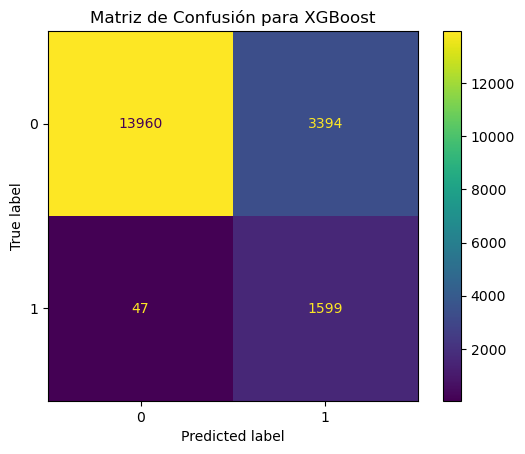


Reporte de Clasificación para XGBoost:
              precision    recall  f1-score   support

           0       1.00      0.80      0.89     17354
           1       0.32      0.97      0.48      1646

    accuracy                           0.82     19000
   macro avg       0.66      0.89      0.69     19000
weighted avg       0.94      0.82      0.85     19000



In [41]:
# Definimos el espacio de búsqueda para XGBoost
param_distributions_xgb = {
    'objective': ['binary:logistic'], # Para clasificación binaria
    'eval_metric': ['logloss'], # Métrica de evaluación durante el entrenamiento
    'n_estimators': randint(100, 500), # Número de árboles (iteraciones de boosting)
    'learning_rate': uniform(0.01, 0.3), # Tasa de aprendizaje
    'max_depth': randint(3, 10), # Profundidad máxima de cada árbol
    'min_child_weight': randint(1, 10), # Peso mínimo de la instancia en un nodo hijo
    'gamma': uniform(0, 0.5), # Reducción de pérdida mínima necesaria para hacer una partición en un nodo hoja del árbol
    'subsample': uniform(0.6, 0.4), # Fracción de muestras utilizadas para entrenar cada árbol
    'colsample_bytree': uniform(0.6, 0.4), # Fracción de características utilizadas para entrenar cada árbol
    'lambda': uniform(1, 2), # Regularización L2
    'alpha': uniform(0, 1), # Regularización L1
    'scale_pos_weight': [20] # Ponderación de clases para manejar el desbalance
}

# Inicializamos RandomizedSearchCV para XGBoost
random_search_xgb = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(random_state=42),
    param_distributions=param_distributions_xgb,
    n_iter=50, # Reducimos el número de iteraciones para explorar más combinaciones
    cv=5,
    scoring='recall', # Optimizamos para recall
    random_state=42,
    n_jobs=-1 # Usamos todos los núcleos disponibles
)

# Ajustamos a los datos de entrenamiento
print("Iniciando RandomizedSearchCV para XGBoost...")
random_search_xgb.fit(x_train, y_train)
print("RandomizedSearchCV para XGBoost finalizado.")

# Mostramos los mejores parámetros encontrados
print("\nMejores parámetros para XGBoost:", random_search_xgb.best_params_)

# Evaluamos el mejor modelo en el conjunto de prueba
best_xgb_model = random_search_xgb.best_estimator_
test_predictions_xgb = best_xgb_model.predict(x_test)

# Calculamos y mostramos el recall en el conjunto de prueba
recall_xgb = recall_score(y_test, test_predictions_xgb)
print(f"\nRecall en el conjunto de prueba con XGBoost (mejores parámetros): {recall_xgb * 100.0:.2f}%")

# Mostramos la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions_xgb)
plt.title('Matriz de Confusión para XGBoost')
plt.show()

# Mostramos el reporte de clasificación
print("\nReporte de Clasificación para XGBoost:")
print(classification_report(y_test, test_predictions_xgb))

In [42]:
# Realizar validación cruzada con los mejores parámetros encontrados
FOLDS = 5
cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=10)

x_train_np = np.array(x_train)
y_train_np = np.array(y_train)

print(f"\nRealizando validación cruzada (StratifiedKFold con {FOLDS} folds) para el mejor modelo XGBoost...")

clfi_xgb_2 = xgb.XGBClassifier(**random_search_xgb.best_params_, random_state=42)
avg_recall_xgb = 0

for fold, (train_idx, val_idx) in enumerate(cv.split(x_train_np, y_train_np)):
    xi, yi = x_train_np[train_idx], y_train_np[train_idx]
    x_valid, y_valid = x_train_np[val_idx], y_train_np[val_idx]

    clfi_xgb_2.fit(xi, yi)

    test_predictions_fold = clfi_xgb_2.predict(x_valid)
    recall_fold = recall_score(y_valid, test_predictions_fold)
    avg_recall_xgb += recall_fold
    print(f"Recall test fold {fold}: {recall_fold * 100.0:.2f}%")

avg_recall_xgb /= FOLDS
print(f'\nAvg. recall (validación cruzada) = {avg_recall_xgb * 100:.2f}%')


Realizando validación cruzada (StratifiedKFold con 5 folds) para el mejor modelo XGBoost...
Recall test fold 0: 97.51%
Recall test fold 1: 97.59%
Recall test fold 2: 97.36%
Recall test fold 3: 97.28%
Recall test fold 4: 97.83%

Avg. recall (validación cruzada) = 97.51%


Para testear los datos de testeo con este modelo, notemos que ya tenemos previamente definido el X_test. Veamos:

In [43]:
X_test

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,1.216115,0.534851,-0.275614,-0.200374,0.989602,0.683720,-0.950085,-0.294803
1,-0.819565,-0.840774,-0.275614,-0.200374,0.989602,-0.198857,0.997153,-0.195048
2,-0.819565,-0.175149,-0.275614,-0.200374,0.989602,-0.743333,0.626250,-0.294803
3,-0.819565,-0.530149,-0.275614,-0.200374,1.517446,0.540283,-0.486457,-1.441995
4,1.216115,-0.485774,-0.275614,-0.200374,-0.066086,0.196327,0.997153,-0.943216
...,...,...,...,...,...,...,...,...
4995,-0.819565,-0.796399,-0.275614,-0.200374,0.989602,-0.665760,0.997153,1.550679
4996,-0.819565,0.446101,-0.275614,-0.200374,-1.121774,0.000198,-1.413713,0.428426
4997,1.216115,1.688601,-0.275614,-0.200374,-1.121774,-0.515004,0.440799,-0.294803
4998,1.216115,-0.752024,-0.275614,-0.200374,0.989602,-0.678933,0.533525,-1.317300


Por lo tanto:

In [44]:
test_id = PatientId_test
test_pred = np.int64(clfi_xgb_2.predict(X_test))

In [45]:
submission = pd.DataFrame(list(zip(test_id, test_pred)), columns=["patient", "diabetes"])
submission.to_csv("sample_submission_xgb2.csv", header=True, index=False)

In [46]:
submission

,patient,diabetes
0,49267,0
1,82280,0
2,33216,0
3,94551,0
4,43760,0
...,...,...
4995,88540,0
4996,26701,0
4997,47271,1
4998,97941,0


---
### **Random Forest**

Por ultimo, entrenamos también un RandomForest.


Iniciando RandomizedSearchCV para Random Forest...
RandomizedSearchCV para Random Forest finalizado.

Mejores parámetros para Random Forest: {'class_weight': 'balanced_subsample', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 7, 'n_estimators': 153}

Recall en el conjunto de prueba con Random Forest (mejores parámetros): 90.77%


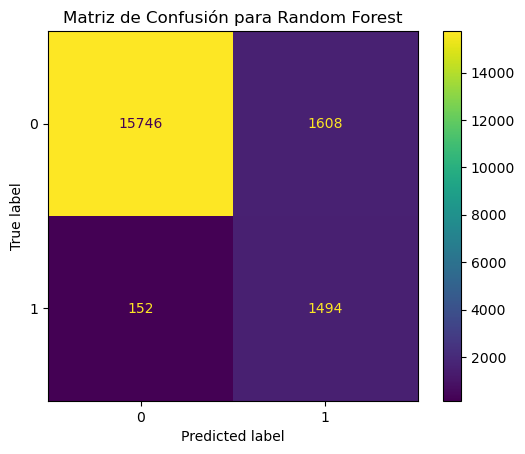


Reporte de Clasificación para Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     17354
           1       0.48      0.91      0.63      1646

    accuracy                           0.91     19000
   macro avg       0.74      0.91      0.79     19000
weighted avg       0.95      0.91      0.92     19000



In [47]:
# Definimos el espacio de búsqueda para Random Forest
param_dist_rf = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 20),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf': randint(1, 10),
    'class_weight': ['balanced', 'balanced_subsample']
}

# Inicializamos RandomizedSearchCV para Random Forest
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=3,
    scoring='recall',
    random_state=42,
    n_jobs=-1
)

# Ajustamos a los datos de entrenamiento
print("Iniciando RandomizedSearchCV para Random Forest...")
random_search_rf.fit(x_train, y_train)
print("RandomizedSearchCV para Random Forest finalizado.")

# Mostramos los mejores parámetros encontrados
print("\nMejores parámetros para Random Forest:", random_search_rf.best_params_)

# Evaluamos el mejor modelo en el conjunto de prueba
best_rf_model = random_search_rf.best_estimator_
test_predictions_rf = best_rf_model.predict(x_test)

# Calculamos y mostramos el recall en el conjunto de prueba
recall_rf = recall_score(y_test, test_predictions_rf)
print(f"\nRecall en el conjunto de prueba con Random Forest (mejores parámetros): {recall_rf * 100.0:.2f}%")

# Mostramos la matriz de confusión
ConfusionMatrixDisplay.from_predictions(y_test, test_predictions_rf)
plt.title('Matriz de Confusión para Random Forest')
plt.show()

# Mostramos el reporte de clasificación
print("\nReporte de Clasificación para Random Forest:")
print(classification_report(y_test, test_predictions_rf))

In [48]:
if hasattr(random_search_rf, 'best_estimator_'):
    # Realizamos validación cruzada con los mejores parámetros encontrados
    FOLDS = 5
    cv = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=10)

    x_train_np = np.array(x_train)
    y_train_np = np.array(y_train)

    print(f"\nRealizando validación cruzada (StratifiedKFold con {FOLDS} folds) para el primer modelo Random Forest...")

    # Usamos el mejor estimador encontrado por RandomizedSearchCV
    clfi_rf = random_search_rf.best_estimator_
    avg_recall_rf_first_model = 0

    for fold, (train_idx, val_idx) in enumerate(cv.split(x_train_np, y_train_np)):
        xi, yi = x_train_np[train_idx], y_train_np[train_idx]
        x_valid, y_valid = x_train_np[val_idx], y_train_np[val_idx]

        clfi_rf.fit(xi, yi)

        test_predictions_fold = clfi_rf.predict(x_valid)
        recall_fold = recall_score(y_valid, test_predictions_fold)
        avg_recall_rf_first_model += recall_fold
        print(f"Recall test fold {fold}: {recall_fold * 100.0:.2f}%")

    avg_recall_rf_first_model /= FOLDS
    print(f'\nAvg. recall (validación cruzada del primer modelo) = {avg_recall_rf_first_model * 100:.2f}%')
else:
    print("Por favor, asegúrate de que la celda que contiene el 'random_search_rf.fit(x_train, y_train)' del primer modelo se haya ejecutado completamente.")


Realizando validación cruzada (StratifiedKFold con 5 folds) para el primer modelo Random Forest...
Recall test fold 0: 92.31%
Recall test fold 1: 92.07%
Recall test fold 2: 91.69%
Recall test fold 3: 90.13%
Recall test fold 4: 91.61%

Avg. recall (validación cruzada del primer modelo) = 91.56%


Para testear los datos de testeo con este modelo, notemos que ya tenemos previamente definido el X_test. Veamos:

In [49]:
X_test

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,1.216115,0.534851,-0.275614,-0.200374,0.989602,0.683720,-0.950085,-0.294803
1,-0.819565,-0.840774,-0.275614,-0.200374,0.989602,-0.198857,0.997153,-0.195048
2,-0.819565,-0.175149,-0.275614,-0.200374,0.989602,-0.743333,0.626250,-0.294803
3,-0.819565,-0.530149,-0.275614,-0.200374,1.517446,0.540283,-0.486457,-1.441995
4,1.216115,-0.485774,-0.275614,-0.200374,-0.066086,0.196327,0.997153,-0.943216
...,...,...,...,...,...,...,...,...
4995,-0.819565,-0.796399,-0.275614,-0.200374,0.989602,-0.665760,0.997153,1.550679
4996,-0.819565,0.446101,-0.275614,-0.200374,-1.121774,0.000198,-1.413713,0.428426
4997,1.216115,1.688601,-0.275614,-0.200374,-1.121774,-0.515004,0.440799,-0.294803
4998,1.216115,-0.752024,-0.275614,-0.200374,0.989602,-0.678933,0.533525,-1.317300


Por lo tanto:

In [50]:
test_id = PatientId_test
test_pred = np.int64(clfi_rf.predict(X_test))

/home/gonzalo/miniconda3/envs/env-diplodatos-as/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


In [51]:
submission = pd.DataFrame(list(zip(test_id, test_pred)), columns=["patient", "diabetes"])
submission.to_csv("sample_submission_rf.csv", header=True, index=False)

In [52]:
submission

,patient,diabetes
0,49267,0
1,82280,0
2,33216,0
3,94551,0
4,43760,0
...,...,...
4995,88540,0
4996,26701,0
4997,47271,0
4998,97941,0
